In [44]:
import os
import numpy as np
import open3d as o3d

# Path to your PLY file (adjust if needed)
PLY_PATH = r"gaussians/single/chair_webots.ply"

# Load point cloud
pcd = o3d.io.read_point_cloud(PLY_PATH)
pts = np.asarray(pcd.points)
print("Loaded point cloud with", pts.shape[0], "points")

print("Point cloud has color:", pcd.has_colors())

Loaded point cloud with 140640 points
Point cloud has color: False


In [ ]:
# Choose voxel size (in same units as the PLY; if already scaled, this is meters)
voxel_size = 0.005  # e.g. 1 cm, tweak as needed

voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=voxel_size)
print("Number of voxels:", len(voxel_grid.get_voxels()))
print("Voxel size:", voxel_size)
print("Voxel grid has color:", voxel_grid.has_colors())
      

Number of voxels: 49008
Voxel size: 0.005
Voxel grid has color: True
Voxel color type: <class 'numpy.ndarray'>
Voxel color example: [0. 0. 0.]


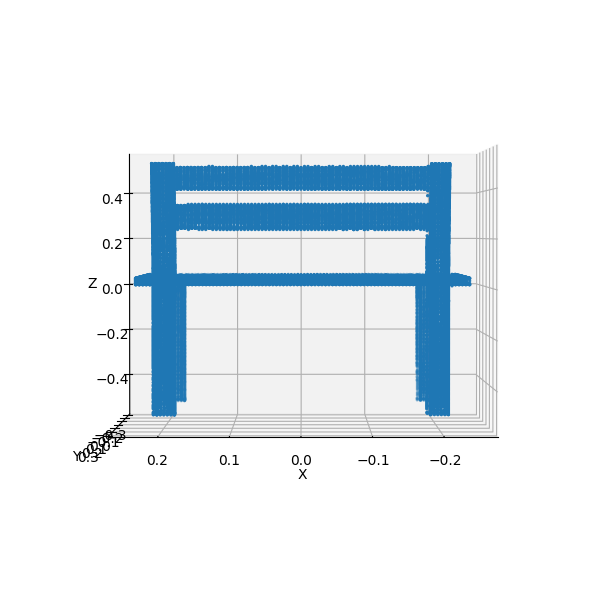

In [40]:
# ...existing code...
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Get voxel centers as (N, 3) array
voxels = voxel_grid.get_voxels()
centers = np.array([
    voxel_grid.get_voxel_center_coordinate(v.grid_index)
    for v in voxels
])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=2)

# Front view (tweak as needed)
ax.view_init(elev=1, azim=90)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()
# ...existing code...

In [41]:
num_voxels = len(voxel_grid.get_voxels())
voxel_volume = (voxel_size ** 3)
total_volume = num_voxels * voxel_volume

print(f"Num voxels:      {num_voxels}")
print(f"Single voxel vol: {voxel_volume:.8f} (units^3)")
print(f"Total volume:     {total_volume:.8f} (units^3)")

Num voxels:      49008
Single voxel vol: 0.00000013 (units^3)
Total volume:     0.00612600 (units^3)


In [43]:
print("Voxel has color:", voxel_grid.has_colors())

Voxel has color: True
